# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [3]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup, data_utils
from src.models import bert

/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B. Data

### B.1. Load sets

In [5]:
data_frac = data_utils.DATA_FRACTION

df_train, df_val, df_test = data_utils.load_datasets()

### B.2. Shrink dataset size for development purpose

In [6]:
# Comment out this cell to use the full dataset. This is just for quick testing.
train_size = 100
val_size = int(train_size * len(df_val) / len(df_train))
test_size = int(train_size * len(df_test) / len(df_train))

df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)

In [7]:
# Load data as Hugging Face Datasets
ds_train, ds_val, ds_test = bert.create_datasets(df_train, df_val, df_test)

## C. Tokenization

In [8]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [9]:
bert.max_length_dist(df_train, 'tweet_text', tokenizer)

90th percentile: 48.5
95th percentile: 50.74999999999999
99th percentile: 52.55
Absolute Maximum length: 53


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [10]:
save_path = Path(f"../tokens/BERT/{data_frac}")
train_tokenized, val_tokenized, test_tokenized = bert.load_or_tokenize(
    ds_train, ds_val, ds_test, tokenizer, save_path
    , force_retokenize=True
)

Tokenizing datasets...


Map: 100%|██████████| 21/21 [00:00<00:00, 5261.67 examples/s]


Saving tokenized datasets to ../tokens/BERT/0.1...


Saving the dataset (1/1 shards): 100%|██████████| 21/21 [00:00<00:00, 1497.41 examples/s]


## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

### B.1. Preparation

In [11]:
device = setup.setup_device_with_seeds()

batch_size = 16
learning_rate = 5e-5
num_epochs = 3
patience = 2  # early stopping, if validation loss does not improve for this many epochs

train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

Using device: mps


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [12]:
model, train_loss_history, val_loss_history, val_acc_history = bert.finetune(train_tokenized, val_tokenized, configs)

Starting BertForSequenceClassification fine-tuning...
Using device: mps
Number of training samples: 100
Number of validation samples: 21
Batch size: 16
Number of epochs: 3
Early stopping patience: 2 epochs
--------------------------------------------------


Validating Epoch 1/3: 100%|██████████| 2/2 [00:00<00:00,  5.21it/s]


Epoch 1/3 | Train Loss: 0.5728 | Val Loss: 0.4090 | Val Acc: 0.7143


Validating Epoch 2/3: 100%|██████████| 2/2 [00:00<00:00,  9.45it/s]


Epoch 2/3 | Train Loss: 0.5243 | Val Loss: 0.3281 | Val Acc: 0.7619


Validating Epoch 3/3: 100%|██████████| 2/2 [00:00<00:00,  9.31it/s]


Epoch 3/3 | Train Loss: 0.2715 | Val Loss: 0.2625 | Val Acc: 0.8095
Loaded best model with Val Loss: 0.2625


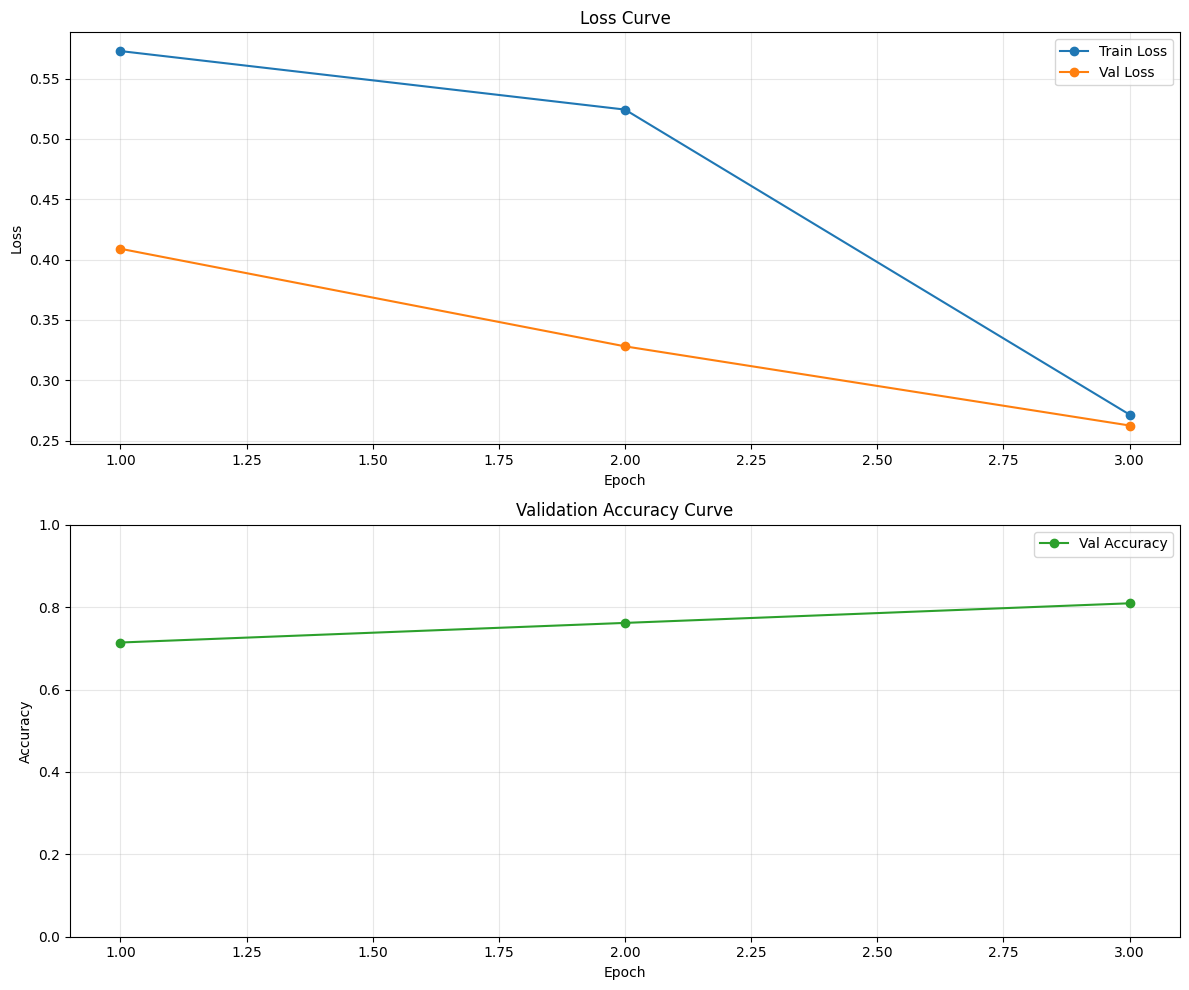

In [13]:
data_utils.plot_fine_tune_history(train_loss_history, val_loss_history, val_acc_history)

### B.3. Predict on the Test set

In [14]:
predictions = bert.predict(model, test_tokenized, device)

Predicting on Test Set: 100%|██████████| 2/2 [00:00<00:00,  8.34it/s]


In [15]:
bert.report_metrics(test_tokenized, predictions)


Classification report:
              precision    recall  f1-score   support

       False     0.9444    0.9444    0.9444        18
        True     0.6667    0.6667    0.6667         3

    accuracy                         0.9048        21
   macro avg     0.8056    0.8056    0.8056        21
weighted avg     0.9048    0.9048    0.9048        21



In [19]:
data_utils.group_report_metrics(df_test, predictions, group_by="subset", labels="informative")

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.7500    0.7500    0.7500         4
        True     0.6667    0.6667    0.6667         3

    accuracy                         0.7143         7
   macro avg     0.7083    0.7083    0.7083         7
weighted avg     0.7143    0.7143    0.7143         7

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    1.0000    1.0000         8

    accuracy                         1.0000         8
   macro avg     1.0000    1.0000    1.0000         8
weighted avg     1.0000    1.0000    1.0000         8

 Classification Report for Subset: weather
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    1.0000    1.0000         6

    a